##### HUGO GARCÍA SOUTO

# Image classification 

In this second part of the notebook you will solve the image classification problem using a convolutional neural network. We are going to use the torch library.


Requirements:
- Torch
- Torchvision
- Numpy
- Matplotlib

## Convolutional Neural Networks

The algorithm to classify images using a convolutional neural network consists of three steps:

1. Load the samples
2. Define the net architecture
2. Train the model with the samples

Let's implement them but, first of all, we are going to define the device where the code will run, gpu (cuda, mps) or cpu.

In [3]:
import torch

if torch.cuda.is_available():
    device_name = "cuda"
elif torch.backends.mps.is_available():
    device_name = "mps"
else:
    device_name = "cpu"
    
device = torch.device(device_name)
print(f"Code runs in {device}")


Code runs in cpu


### Step 1: Load the samples

In order to feed the net in batches, we are going to extend the class Dataset from the torch library. An instance of this class will load all the samples in a dataset (train/test). The parameter `transform` in the constructor defines a sequence of transformations to be applied to the dataset images.


In [4]:
import numpy as np
import matplotlib.pyplot as plt
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import csv


class FashionDataset(Dataset):
    """User defined class to build a datset using Pytorch class Dataset."""
    
    def __init__(self, filename, transform = None):
        self.images, self.labels = self.load_mnist_dataset(filename)
        self.transform = transform
        
        
    def __getitem__(self, index):
        label = self.labels[index]
        image = self.images[index]
        
        if self.transform is not None:
            image = self.transform(image)

        return image, label

    def __len__(self):
        return len(self.images)


    def load_mnist_dataset(self, filename):
        f = open(filename, 'r')
        reader = csv.reader(f, delimiter=',')
        data = []
        images = []
        labels = []
        next(reader)
        for row in reader:
            labels.append(int(row[0]))
            images.append(np.array(row[1:]).astype(np.uint8).reshape(28,28))
        return np.array(images).astype(np.float32), np.array(labels)



Now, you can load the samples:

In [5]:
train_valid_dataset = FashionDataset("res/fashion-mnist_train.csv", 
            transform=transforms.Compose([transforms.ToTensor()]))
test_dataset = FashionDataset("res/fashion-mnist_test.csv", 
            transform=transforms.Compose([transforms.ToTensor()]))

and visualize them:

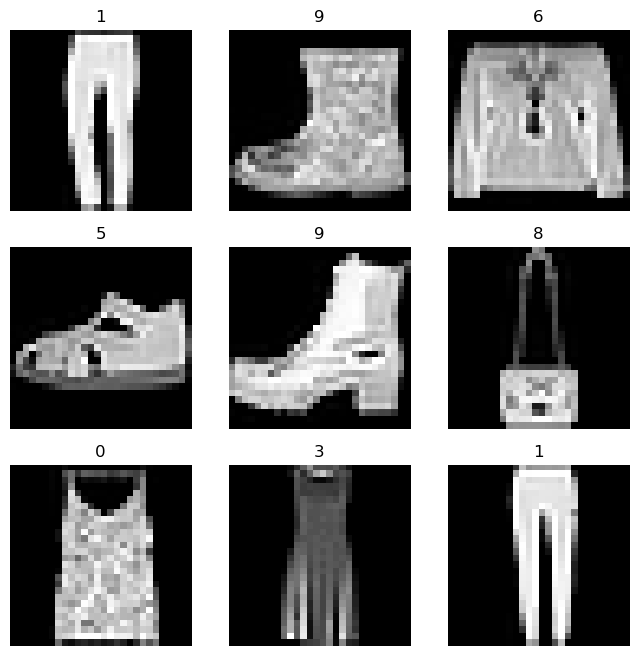

In [6]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 3
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(train_valid_dataset), size=(1,)).item()
    img, label = train_valid_dataset[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze(), cmap="gray")
plt.show()

In deep learning, it is usual to divide the training dataset into three datasets: train, validation and test. The former is used to update the weights of the model; the second one is used to check the performance of our model during the training stage whereas the later is used to test the accuracy of the model with unseen samples. 

In our case, the Fashion-MNIST dataset consists only on a training and a test files so we are going to create a validation dataset from the training data with a 20% of the samples in this dataset.

In [7]:
VALID_RATIO = 0.2

num_train = int((1.0 - VALID_RATIO) * len(train_valid_dataset))
num_valid = len(train_valid_dataset) - num_train

print(f"Number of samples: training = {num_train} | validation = {num_valid}")

train_dataset, valid_dataset = torch.utils.data.dataset.random_split(train_valid_dataset, [num_train, num_valid])


Number of samples: training = 48000 | validation = 12000


### Step 2: Model architecture
In the second step, we are going to define the model architecture. 
We are going to start with a toy cnn with only a convolutional layer and two fully connected layers. In torch, the net is a subclass of `nn.Module`. The architecture is declared in the constructor of the class and the way the samples are feeded to the net is defined in the `forward` method:

In [8]:
import torch.nn as nn

class ToyCNN(nn.Module):

    def __init__(self):
        super(ToyCNN, self).__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels = 1, 
                out_channels = 32, 
                kernel_size=5),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )
        
        self.fc1 = nn.Linear(in_features=32*12*12, out_features=600)
        self.fc2 = nn.Linear(in_features=600, out_features=10)


    def forward(self, x):
        out = self.conv1(x)
        # Flatten output of the previous conv layer to feed the next fc layer
        out = out.view(out.size(0), -1) 
        out = self.fc1(out)
        out = self.fc2(out)
        
        return out



**Important**: This net is adapted to the Fashion-MNIST image size. The input size of the first fully connected layer depends on the size of the previous layer. In order to compute the output size of a convolutional or a pooling layer, take into account the following equation:

$output\_size = \dfrac{input\_size + 2 * padding - kernel\_size}{stride} + 1$

### Step 3: train the model

The last step is training the model with the provided samples. The following function trains  a convolutional neural network **one epoch** with the train and validation datasets: the weights are updated using the training samples and the loss is computed in the validation dataset.

In [9]:
def train(model, loader, f_loss, optimizer, device):
    count = 0
    total_loss = 0.0
    correct = 0

    model.train()
    for i, (inputs, targets) in enumerate(loader):
        inputs = inputs.to(device)
        targets = targets.to(device).long()

        # Forward pass
        outputs = model(inputs)

        # Compute the loss
        loss = f_loss(outputs, targets)

        # Accumulate the number of processed samples
        count += inputs.shape[0]

        # Accumulate the total loss
        total_loss += inputs.shape[0] * loss.item()

        # Compute total accuracy
        predictions = outputs.argmax(dim=1)
        correct += (predictions == targets).sum().item()

        # Backpropagate the error to change the model weights
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    return total_loss / count, correct / count

The following code trains the `ToyCNN` model one epoch using the `CrossEntropyLoss` as function loss and the `Adam` optimizer:

In [10]:
from torch.optim import Adam

model = ToyCNN()
model.to(device)

batch_size = 64
f_loss = nn.CrossEntropyLoss()
optimizer=Adam(model.parameters(), lr=0.0001)

train_loader = DataLoader(train_dataset, batch_size=batch_size)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size)

loss, acc = train(model, train_loader, f_loss, optimizer, device)
torch.save(model, 'trained-model.pt')
print(f"Epoch 1 (training): Loss = {loss} | Accuracy = {acc}")

Epoch 1 (training): Loss = 3.7529581214586893 | Accuracy = 0.796375


The following function computes the predictions so we can use it to check the performance of our model in the validation dataset:

In [11]:
def test(model, loader, f_loss, device):
    count = 0
    total_loss = 0.0
    correct = 0

    model.eval()

    with torch.no_grad():
        for i, (inputs, targets) in enumerate(loader):
            inputs = inputs.to(device)
            targets = targets.to(device).long()

            # Forward pass
            outputs = model(inputs)

            # Compute the loss
            loss = f_loss(outputs, targets)

            # Accumulate the number of processed samples
            count += inputs.shape[0]

            # Accumulate the total loss
            total_loss += inputs.shape[0] * loss.item()

            # Compute total accuracy
            predictions = outputs.argmax(dim=1)
            correct += (predictions == targets).sum().item()

    return total_loss / count, correct / count

In [12]:
loss, acc = test(model, valid_loader, f_loss, device)
print(f"Epoch 1 (validation): Loss = {loss} | Accuracy = {acc}")

Epoch 1 (validation): Loss = 1.7379433422088624 | Accuracy = 0.8433333333333334


#### Exercise
Write a function that trains the model for a given number of epochs. The function should output both validation loss and accuracy for each epoch. It should also save the model with the lowest validation error during the training stage and plot both the validation loss and accuracy through epochs. 

In [ ]:
def train_model(model, train_dataset, valid_dataset, device,
                optimizer, 
                loss,
                batch_size=128, 
                num_epochs=20,
                output_filename='trained-model.pt'):
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_loader = DataLoader(valid_dataset, batch_size=batch_size)
    
    train_losses = []
    train_accuracies = []
    valid_losses = []
    valid_accuracies = []

    best_valid_loss = float("inf")

    for epoch in range(num_epochs):
        # Train one epoch
        train_loss, train_acc = train(
            model=model,
            loader=train_loader,
            f_loss=loss,
            optimizer=optimizer,
            device=device
        )

        # Evaluate on validation dataset
        valid_loss, valid_acc = test(
            model=model,
            loader=valid_loader,
            f_loss=loss,
            device=device
        )

        # Store results
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)
        valid_losses.append(valid_loss)
        valid_accuracies.append(valid_acc)

        print(
            f"Epoch {epoch + 1}/{num_epochs} | "
            f"Train Loss = {train_loss:.4f} | "
            f"Train Accuracy = {train_acc:.4f} | "
            f"Validation Loss = {valid_loss:.4f} | "
            f"Validation Accuracy = {valid_acc:.4f}"
        )

        # Save the model with the lowest validation loss
        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(model, output_filename)
            print(f"Best model saved with validation loss = {best_valid_loss:.4f}")

    # Plot validation loss
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_epochs + 1), valid_losses, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Validation Loss")
    plt.title("Validation Loss through Epochs")
    plt.grid(True)
    plt.show()

    # Plot validation accuracy
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, num_epochs + 1), valid_accuracies, marker='o')
    plt.xlabel("Epoch")
    plt.ylabel("Validation Accuracy")
    plt.title("Validation Accuracy through Epochs")
    plt.grid(True)
    plt.show()

    return train_losses, train_accuracies, valid_losses, valid_accuracies

            
    

Epoch 1/20 | Train Loss = 5.0209 | Train Accuracy = 0.7801 | Validation Loss = 1.9932 | Validation Accuracy = 0.8375
Best model saved with validation loss = 1.9932
Epoch 2/20 | Train Loss = 1.7587 | Train Accuracy = 0.8421 | Validation Loss = 1.1665 | Validation Accuracy = 0.8627
Best model saved with validation loss = 1.1665
Epoch 3/20 | Train Loss = 1.1781 | Train Accuracy = 0.8654 | Validation Loss = 1.0537 | Validation Accuracy = 0.8660
Best model saved with validation loss = 1.0537
Epoch 4/20 | Train Loss = 0.9028 | Train Accuracy = 0.8767 | Validation Loss = 1.3153 | Validation Accuracy = 0.8472
Epoch 5/20 | Train Loss = 0.7560 | Train Accuracy = 0.8851 | Validation Loss = 0.7776 | Validation Accuracy = 0.8818
Best model saved with validation loss = 0.7776
Epoch 6/20 | Train Loss = 0.5233 | Train Accuracy = 0.8988 | Validation Loss = 0.7036 | Validation Accuracy = 0.8766
Best model saved with validation loss = 0.7036
Epoch 7/20 | Train Loss = 0.4269 | Train Accuracy = 0.9057 | Va

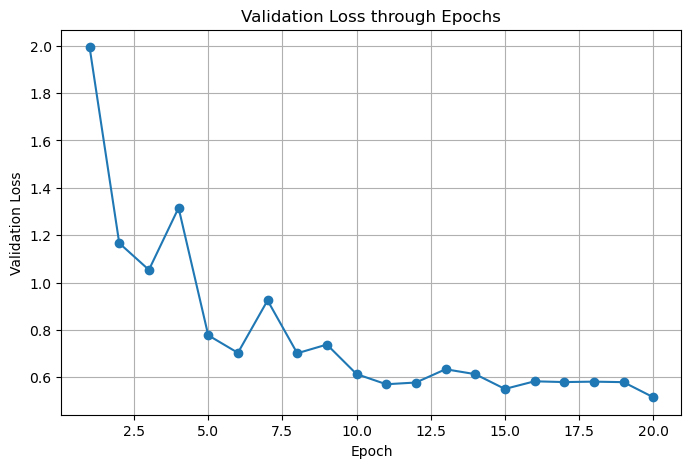

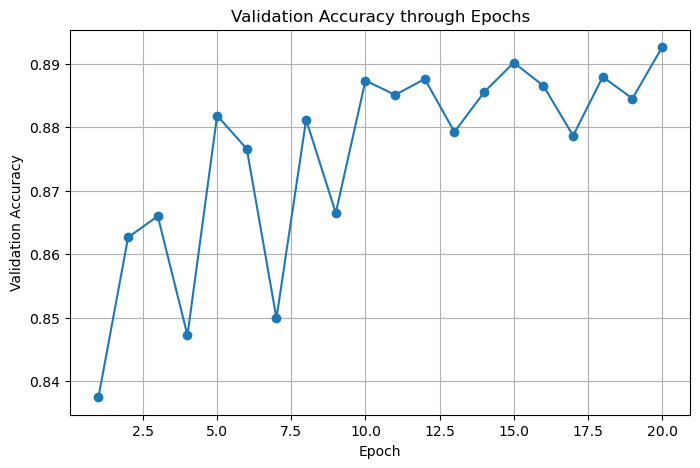

In [15]:
# IMPORTANT: adapt the batch size to your hardware requirements!
model = ToyCNN()
model.to(device)

optimizer = Adam(model.parameters(), lr=0.0001)

history_toycnn = train_model(
    model=model,
    train_dataset=train_dataset,
    valid_dataset=valid_dataset,
    device=device,
    optimizer=optimizer,
    loss=f_loss,
    batch_size=128,
    num_epochs=20,
    output_filename='trained-model.pt'
)

The ToyCNN model was trained from scratch for 20 epochs. During training, the training loss decreases clearly and the training accuracy increases from 0.7801 to 0.9419, which shows that the model is learning useful visual patterns from the training images.

The validation accuracy also improves during training, reaching a final value of 0.8926. The best model was saved at epoch 20, where the lowest validation loss was obtained. This suggests that, although the model starts to overfit slightly because the training accuracy is higher than the validation accuracy, the validation performance is still improving at the end of training.

Compared with the Bag of Visual Words approach, the CNN obtains a much higher validation accuracy because it learns spatial filters directly from the image pixels instead of relying on handcrafted local descriptors.

#### Exercise
Compute the success rate in the test dataset by loading the best model that have been saved.

In [ ]:
model = torch.load('trained-model.pt', map_location=device)
model.to(device)

# Create the test dataloader
test_loader = DataLoader(test_dataset, batch_size=128)

# Evaluate the best saved model on the test dataset
test_loss, test_acc = test(
    model=model,
    loader=test_loader,
    f_loss=f_loss,
    device=device
)

print(f"Test Loss = {test_loss:.4f} | Test Accuracy = {test_acc:.4f}")



Test Loss = 0.5184 | Test Accuracy = 0.8917


The best ToyCNN model obtained a test accuracy of 0.8917. This result is very close to the validation accuracy obtained during training, which suggests that the model generalizes well to unseen samples.

Compared with the Bag of Visual Words approach, whose test accuracy was 0.5784, the convolutional neural network achieves a much better performance. This improvement is expected because CNNs learn spatial filters directly from the image pixels, while Bag of Visual Words ignores much of the spatial structure of the image.

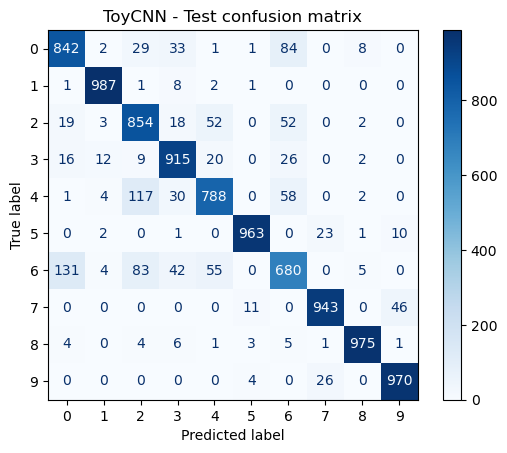

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

all_predictions = []
all_targets = []

model.eval()

with torch.no_grad():
    for inputs, targets in test_loader:
        inputs = inputs.to(device)
        targets = targets.to(device).long()

        outputs = model(inputs)
        predictions = outputs.argmax(dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(targets.cpu().numpy())

cm = confusion_matrix(all_targets, all_predictions)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues", values_format="d")
plt.title("ToyCNN - Test confusion matrix")
plt.show()

#### Exercise
Define another model architecture with two convolutional layers and three fully connected layers. Train the model and test the accuracy in the test dataset.

**Hint**: increase the learning rate (e.g. 0.001)

In [18]:
class FashionMNISTCNN(nn.Module):

    def __init__(self):
        super(FashionMNISTCNN, self).__init__()

        # Input: 1 x 28 x 28
        # Output after conv1 + pooling: 32 x 14 x 14
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Input: 32 x 14 x 14
        # Output after conv2 + pooling: 64 x 7 x 7
        self.conv2 = nn.Sequential(
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Fully connected layers
        self.fc1 = nn.Linear(in_features=64 * 7 * 7, out_features=256)
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=10)


    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)

        # Flatten: batch_size x (64*7*7)
        out = out.view(out.size(0), -1)

        out = self.fc1(out)
        out = torch.relu(out)

        out = self.fc2(out)
        out = torch.relu(out)

        out = self.fc3(out)

        return out


Epoch 1/20 | Train Loss = 0.4807 | Train Accuracy = 0.8404 | Validation Loss = 0.3094 | Validation Accuracy = 0.8893
Best model saved with validation loss = 0.3094
Epoch 2/20 | Train Loss = 0.2751 | Train Accuracy = 0.8993 | Validation Loss = 0.2809 | Validation Accuracy = 0.9008
Best model saved with validation loss = 0.2809
Epoch 3/20 | Train Loss = 0.2322 | Train Accuracy = 0.9120 | Validation Loss = 0.2494 | Validation Accuracy = 0.9090
Best model saved with validation loss = 0.2494
Epoch 4/20 | Train Loss = 0.1967 | Train Accuracy = 0.9253 | Validation Loss = 0.2493 | Validation Accuracy = 0.9143
Best model saved with validation loss = 0.2493
Epoch 5/20 | Train Loss = 0.1717 | Train Accuracy = 0.9359 | Validation Loss = 0.2406 | Validation Accuracy = 0.9191
Best model saved with validation loss = 0.2406
Epoch 6/20 | Train Loss = 0.1487 | Train Accuracy = 0.9438 | Validation Loss = 0.2780 | Validation Accuracy = 0.9113
Epoch 7/20 | Train Loss = 0.1309 | Train Accuracy = 0.9505 | Va

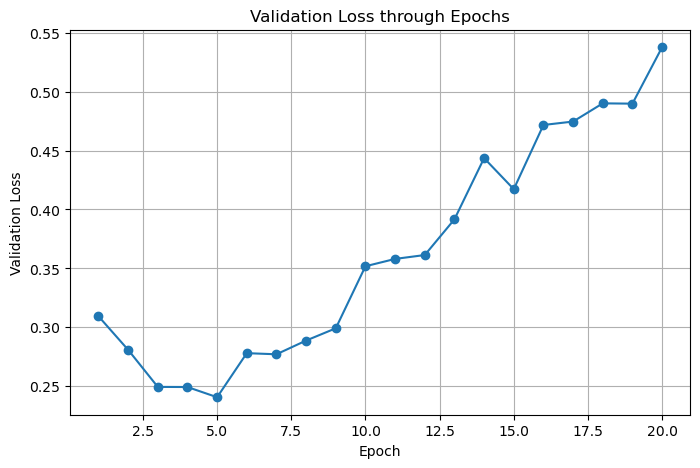

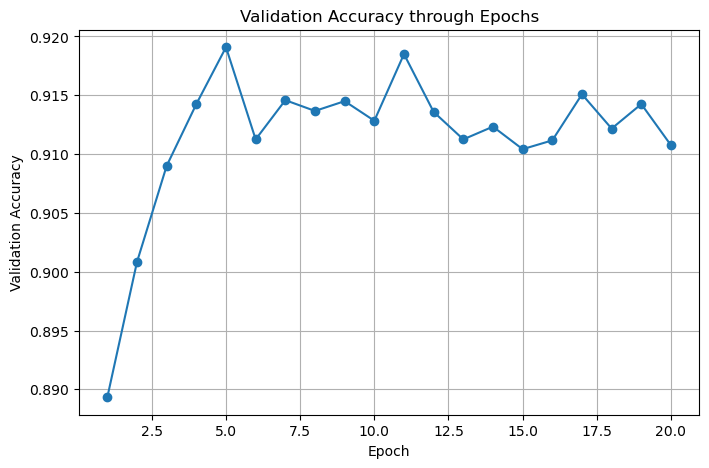

In [19]:
model = FashionMNISTCNN()
model.to(device)

optimizer = Adam(model.parameters(), lr=0.001)

history_cnn_v2 = train_model(
    model=model,
    train_dataset=train_dataset,
    valid_dataset=valid_dataset,
    device=device,
    optimizer=optimizer,
    loss=f_loss,
    batch_size=128,
    num_epochs=20,
    output_filename='trained-model-v2.pt'
)

In [20]:
model = torch.load('trained-model-v2.pt', map_location=device)
model.to(device)

test_loader = DataLoader(test_dataset, batch_size=128)

test_loss_v2, test_acc_v2 = test(
    model=model,
    loader=test_loader,
    f_loss=f_loss,
    device=device
)

print(f"Test Loss = {test_loss_v2:.4f} | Test Accuracy = {test_acc_v2:.4f}")

C:\Users\Hugo\AppData\Local\Temp\ipykernel_16976\3999889523.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('trained-model-v2.pt', map_location=device

Test Loss = 0.2265 | Test Accuracy = 0.9157


The second CNN architecture obtained a test accuracy of 0.9157, improving the result obtained with the ToyCNN model, whose test accuracy was 0.8917.

This improvement is expected because the new architecture contains two convolutional layers instead of one. Therefore, the network can learn more complex visual features. The first convolutional layer can learn simple low-level patterns such as edges or local contrasts, while the second convolutional layer can combine those patterns into more informative structures.

During training, the best validation loss was obtained at epoch 5. After that point, the training accuracy continued increasing, but the validation loss also increased. This indicates overfitting: the model keeps improving on the training set but does not generalize better to validation data.

The saved model corresponds to the epoch with the lowest validation loss, so the final test accuracy is computed using the best version of the model observed during training.

#### Exercise
Replicate the previous architecture but include [batch normalization](https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm2d.html) before the ReLU layer and [dropout](https://pytorch.org/docs/stable/generated/torch.nn.Dropout.html?highlight=dropout#torch.nn.Dropout) between two consecutive fully conected layers. Train the  model and check if these strategies have improved the accuracy in the test dataset.

In [21]:
class FashionMNISTv2CNN(nn.Module):

    def __init__(self):
        super(FashionMNISTv2CNN, self).__init__()

        # Input: 1 x 28 x 28
        # Output: 32 x 14 x 14
        self.conv1 = nn.Sequential(
            nn.Conv2d(
                in_channels=1,
                out_channels=32,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        # Input: 32 x 14 x 14
        # Output: 64 x 7 x 7
        self.conv2 = nn.Sequential(
            nn.Conv2d(
                in_channels=32,
                out_channels=64,
                kernel_size=3,
                padding=1
            ),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.fc1 = nn.Linear(in_features=64 * 7 * 7, out_features=256)
        self.drop = nn.Dropout(p=0.5)
        self.fc2 = nn.Linear(in_features=256, out_features=128)
        self.fc3 = nn.Linear(in_features=128, out_features=10)


    def forward(self, x):
        out = self.conv1(x)
        out = self.conv2(out)

        # Flatten: batch_size x (64*7*7)
        out = out.view(out.size(0), -1)

        out = self.fc1(out)
        out = torch.relu(out)
        out = self.drop(out)

        out = self.fc2(out)
        out = torch.relu(out)
        out = self.drop(out)

        out = self.fc3(out)

        return out

Epoch 1/20 | Train Loss = 0.6168 | Train Accuracy = 0.7796 | Validation Loss = 0.3354 | Validation Accuracy = 0.8742
Best model saved with validation loss = 0.3354
Epoch 2/20 | Train Loss = 0.3956 | Train Accuracy = 0.8631 | Validation Loss = 0.2837 | Validation Accuracy = 0.8983
Best model saved with validation loss = 0.2837
Epoch 3/20 | Train Loss = 0.3451 | Train Accuracy = 0.8794 | Validation Loss = 0.2632 | Validation Accuracy = 0.9065
Best model saved with validation loss = 0.2632
Epoch 4/20 | Train Loss = 0.3133 | Train Accuracy = 0.8900 | Validation Loss = 0.2671 | Validation Accuracy = 0.9012
Epoch 5/20 | Train Loss = 0.2839 | Train Accuracy = 0.8996 | Validation Loss = 0.2524 | Validation Accuracy = 0.9092
Best model saved with validation loss = 0.2524
Epoch 6/20 | Train Loss = 0.2680 | Train Accuracy = 0.9063 | Validation Loss = 0.2380 | Validation Accuracy = 0.9144
Best model saved with validation loss = 0.2380
Epoch 7/20 | Train Loss = 0.2526 | Train Accuracy = 0.9103 | Va

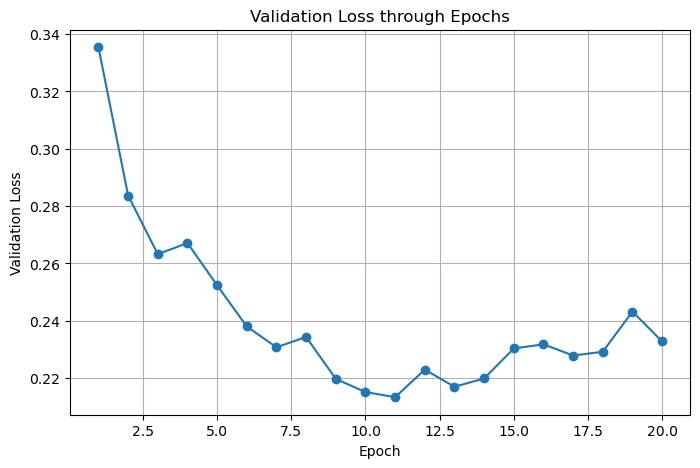

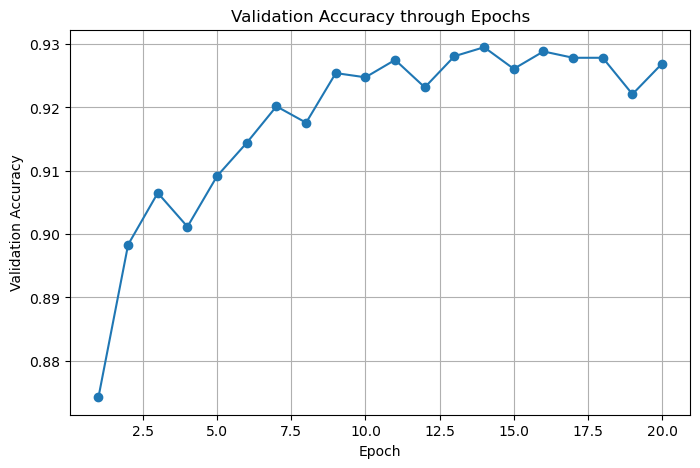

In [22]:
model = FashionMNISTv2CNN()
model.to(device)

optimizer = Adam(model.parameters(), lr=0.001)

history_cnn_v3 = train_model(
    model=model,
    train_dataset=train_dataset,
    valid_dataset=valid_dataset,
    device=device,
    optimizer=optimizer,
    loss=f_loss,
    batch_size=128,
    num_epochs=20,
    output_filename='trained-model-v3.pt'
)

In [23]:
model = torch.load('trained-model-v3.pt', map_location=device)
model.to(device)

test_loader = DataLoader(test_dataset, batch_size=128)

test_loss_v3, test_acc_v3 = test(
    model=model,
    loader=test_loader,
    f_loss=f_loss,
    device=device
)

print(f"Test Loss = {test_loss_v3:.4f} | Test Accuracy = {test_acc_v3:.4f}")

C:\Users\Hugo\AppData\Local\Temp\ipykernel_16976\2390943477.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model = torch.load('trained-model-v3.pt', map_location=device

Test Loss = 0.2126 | Test Accuracy = 0.9242


The third architecture, which includes batch normalization and dropout, obtained a test accuracy of 0.9242. This is slightly better than the previous CNN architecture, which obtained a test accuracy of 0.9157.

Although the improvement in accuracy is not very large, the test loss also decreased from 0.2265 to 0.2126. This suggests that batch normalization and dropout helped the model generalize slightly better.

During training, the model with batch normalization and dropout had a lower training accuracy than the previous CNN, but a better validation and test performance. This is expected because dropout acts as a regularization technique: it makes the training task harder, but helps reduce overfitting.

The best validation loss was obtained around epoch 11. After that point, the training accuracy continued increasing, but the validation loss did not improve significantly. This indicates that the model started to overfit slightly, although less severely than the previous architecture.

In [25]:
import pandas as pd

cnn_results = pd.DataFrame([
    {
        "Model": "ToyCNN",
        "Description": "1 convolutional layer + 2 fully connected layers",
        "Test Loss": 0.5184,
        "Test Accuracy": 0.8917
    },
    {
        "Model": "FashionMNISTCNN",
        "Description": "2 convolutional layers + 3 fully connected layers",
        "Test Loss": 0.2265,
        "Test Accuracy": 0.9157
    },
    {
        "Model": "FashionMNISTv2CNN",
        "Description": "2 convolutional layers + batch normalization + dropout",
        "Test Loss": 0.2126,
        "Test Accuracy": 0.9242
    }
])

cnn_results

,Model,Description,Test Loss,Test Accuracy
0,ToyCNN,1 convolutional layer + 2 fully connected layers,0.5184,0.8917
1,FashionMNISTCNN,2 convolutional layers + 3 fully connected layers,0.2265,0.9157
2,FashionMNISTv2CNN,2 convolutional layers + batch normalization +...,0.2126,0.9242


In conclusion, the best CNN model was the FashionMNISTv2CNN architecture, which included two convolutional layers, batch normalization and dropout. This model achieved the highest test accuracy, with a value of 0.9242.

The results show that increasing the depth of the network from one convolutional layer to two convolutional layers significantly improves the classification performance. The ToyCNN model obtained a test accuracy of 0.8917, while the deeper CNN reached 0.9157.

Adding batch normalization and dropout produced a smaller but still positive improvement, increasing the test accuracy to 0.9242 and reducing the test loss. Batch normalization helped stabilize the training process, while dropout helped reduce overfitting between the fully connected layers.

Compared with the Bag of Visual Words approach, whose test accuracy was 0.5784, the CNN-based models perform much better. This confirms that convolutional neural networks are more suitable for image classification tasks because they learn spatial and hierarchical visual features directly from the image pixels.